<a href="https://colab.research.google.com/github/Derlis-1/Tareas-SI/blob/main/02_ebusiness_resuelto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller: Auditoría de Desempeño para Negocios Digitales:

## Parte 1: Análisis de datos sintéticos

En esta parte vamos a analizar un dataset de transacciones y determinar si la estrategia de M-Commerce (App Móvil) es más rentable que el E-Commerce tradicional (Web Desktop).

Vamos a generar una base de datos aleatoria, que simula la salida de un TPS.

In [110]:
import pandas as pd
import numpy as np

# Generar datos simulados
np.random.seed(42)
data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
    'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
    'Total_Venta': np.random.randint(20, 500, 50), # Ventas entre $20 y $500
    'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)
}

df = pd.DataFrame(data)

df

,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
0,1001,Web Desktop,Transferencia,235,Moda
1,1002,App Móvil,PayPal,312,Moda
2,1003,App Móvil,PayPal,118,Electrónica
3,1004,App Móvil,PayPal,191,Moda
4,1005,Web Desktop,PayPal,379,Electrónica
5,1006,Web Desktop,PayPal,233,Electrónica
6,1007,Web Desktop,PayPal,494,Moda
7,1008,App Móvil,Transferencia,54,Moda
8,1009,App Móvil,Transferencia,468,Moda
9,1010,App Móvil,PayPal,246,Hogar


### ¿Qué preguntas deberíamos plantearnos para obtener las respuestas que buscamos?

Buscamos saber cuál de las dos estrategias (M-Commerce o E-Commerce) es la más rentable.

Vamos a crear 4 KPIs para un MIS que nos permitan responder esta pregunta.

### **Objetivo Principal:** Determinar la rentabilidad de las estrategias de M-Commerce (App Móvil) vs. E-Commerce (Web Desktop).

Para ello, analizaremos los siguientes **4 KPIs** clave:

In [111]:

kpi1 = df.groupby('Canal')['Total_Venta'].sum().reset_index()
kpi1.columns = ['Canal', 'Ingreso_Total_USD']
print("KPI 1 – Ingreso Total por Canal:")
print(kpi1.to_string(index=False))


kpi2 = df.groupby('Canal')['Total_Venta'].mean().reset_index()
kpi2.columns = ['Canal', 'Ticket_Promedio_USD']
kpi2['Ticket_Promedio_USD'] = kpi2['Ticket_Promedio_USD'].round(2)
print("\nKPI 2 – Ticket Promedio por Canal:")
print(kpi2.to_string(index=False))


kpi3 = df.groupby('Canal')['ID_Transaccion'].count().reset_index()
kpi3.columns = ['Canal', 'N_Transacciones']
print("\nKPI 3 – Número de Transacciones por Canal:")
print(kpi3.to_string(index=False))


total_ventas = df['Total_Venta'].sum()
kpi4 = df.groupby('Canal')['Total_Venta'].sum().reset_index()
kpi4.columns = ['Canal', 'Ingreso_USD']
kpi4['Participacion_Pct'] = (kpi4['Ingreso_USD'] / total_ventas * 100).round(2)
print("\nKPI 4 – Participación de Mercado por Canal (%):")
print(kpi4.to_string(index=False))


canal_ganador = kpi4.loc[kpi4['Participacion_Pct'].idxmax(), 'Canal']
pct_ganador   = kpi4.loc[kpi4['Participacion_Pct'].idxmax(), 'Participacion_Pct']
print(f"\n→ Canal más rentable: {canal_ganador} con {pct_ganador}% de la facturación total.")

KPI 1 – Ingreso Total por Canal:
      Canal  Ingreso_Total_USD
  App Móvil               6779
Web Desktop               5549

KPI 2 – Ticket Promedio por Canal:
      Canal  Ticket_Promedio_USD
  App Móvil               260.73
Web Desktop               231.21

KPI 3 – Número de Transacciones por Canal:
      Canal  N_Transacciones
  App Móvil               26
Web Desktop               24

KPI 4 – Participación de Mercado por Canal (%):
      Canal  Ingreso_USD  Participacion_Pct
  App Móvil         6779              54.99
Web Desktop         5549              45.01

→ Canal más rentable: App Móvil con 54.99% de la facturación total.


## Parte 2: KPIs para E-Commerce

Para esta parte vamos a utilizar los datos que se encuentran en el repositorio en `/data/ecommerce.zip`

In [112]:

!git clone https://github.com/ivan-carrera/isi26a.git
import pandas as pd

fatal: destination path 'isi26a' already exists and is not an empty directory.


In [113]:
data = pd.read_csv('isi26a/data/ecommerce.zip')
print(f'Total de registros cargados: {len(data)}')
data.head()

Total de registros cargados: 10999


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


### 1. KPIs de Gestión de Logística y Operaciones (Shipment & Warehouse)

Permiten medir la eficiencia en la distribución de los productos electrónicos.

1.1. **Costo Promedio de Envío por Modo de Transporte (Mode of Shipment):** Ayuda a evaluar qué canales (Barco, Avión, Carretera) representan un mayor impacto financiero en relación con el peso del producto.

1.2. **Volumen de Ocupación por Bloque de Bodega (Warehouse Block):** Porcentaje o cantidad total de productos/peso administrados en cada bloque (A, B, C, D, E) para entender la carga operativa de la infraestructura.

1.3. **Peso Promedio del Producto por Modo de Envío:** Para analizar si se está optimizando la logística (ej. si los productos más pesados se están enviando por barco o si se está gastando de más enviándolos por avión).

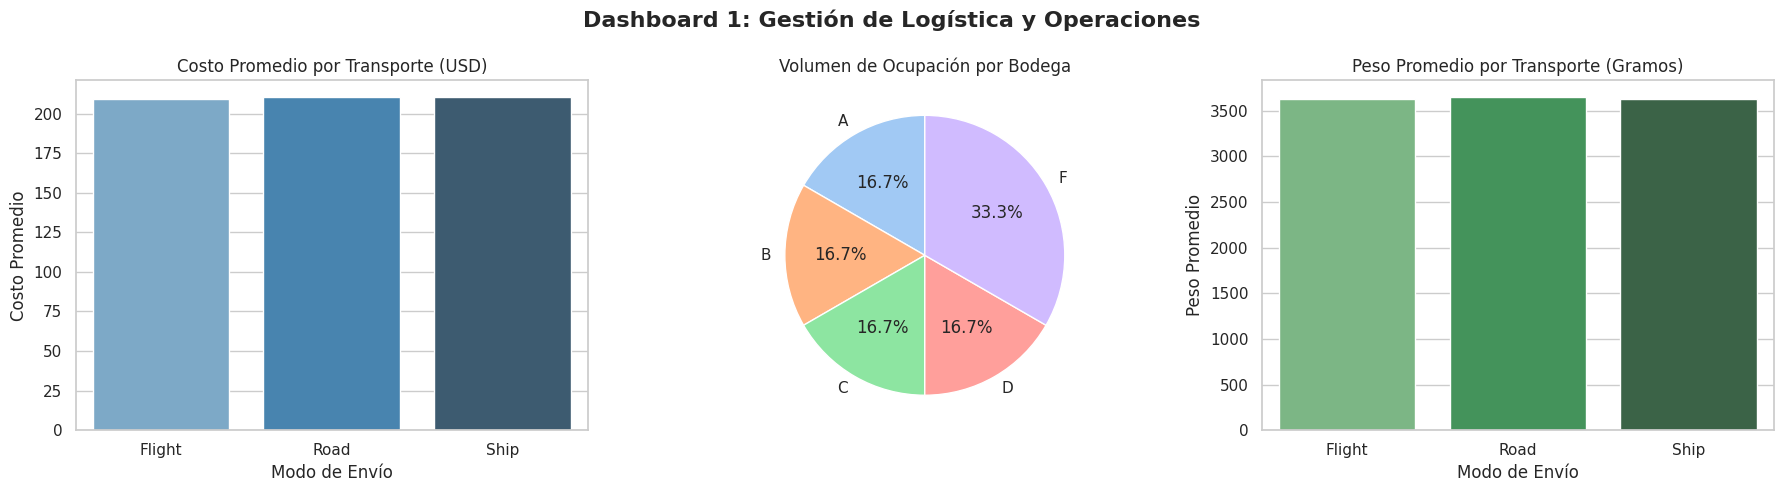

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


kpi1_1 = data.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean().reset_index()
kpi1_2 = data.groupby('Warehouse_block').agg(N_Productos=('ID', 'count')).reset_index()
kpi1_2['Pct_Ocupacion'] = (kpi1_2['N_Productos'] / kpi1_2['N_Productos'].sum() * 100)
kpi1_3 = data.groupby('Mode_of_Shipment')['Weight_in_gms'].mean().reset_index()


fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dashboard 1: Gestión de Logística y Operaciones', fontsize=16, fontweight='bold')


sns.barplot(data=kpi1_1, x='Mode_of_Shipment', y='Cost_of_the_Product', ax=axs[0], palette='Blues_d', hue='Mode_of_Shipment', legend=False)
axs[0].set_title('Costo Promedio por Transporte (USD)')
axs[0].set_xlabel('Modo de Envío')
axs[0].set_ylabel('Costo Promedio')


axs[1].pie(kpi1_2['Pct_Ocupacion'], labels=kpi1_2['Warehouse_block'], autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
axs[1].set_title('Volumen de Ocupación por Bodega')


sns.barplot(data=kpi1_3, x='Mode_of_Shipment', y='Weight_in_gms', ax=axs[2], palette='Greens_d', hue='Mode_of_Shipment', legend=False)
axs[2].set_title('Peso Promedio por Transporte (Gramos)')
axs[2].set_xlabel('Modo de Envío')
axs[2].set_ylabel('Peso Promedio')

plt.tight_layout()
plt.show()

### 2. KPIs de Gestión Comercial y Financiera (Sales & Revenue)

Enfocados en el rendimiento del dinero, los descuentos y la estrategia de precios.

2.1. **Ingreso Total Bruto y Costo Promedio del Producto:** Suma y promedio de la variable `Cost of the product` para entender el ticket promedio de la tienda de electrónica.

2.2. **Porcentaje de Descuento Promedio Otorgado:** Evaluar el impacto de la estrategia de promociones (`Discount offered`) y si los descuentos altos realmente correlacionan con clientes de mayor prioridad o compras previas.

2.3. **Margen Teórico Relativo por Importancia del Producto:** Cruzar `Product importance` (Low, Medium, High) con el costo para ver si los productos catalogados como "alta importancia" son también los más costosos o los que reciben más descuentos.

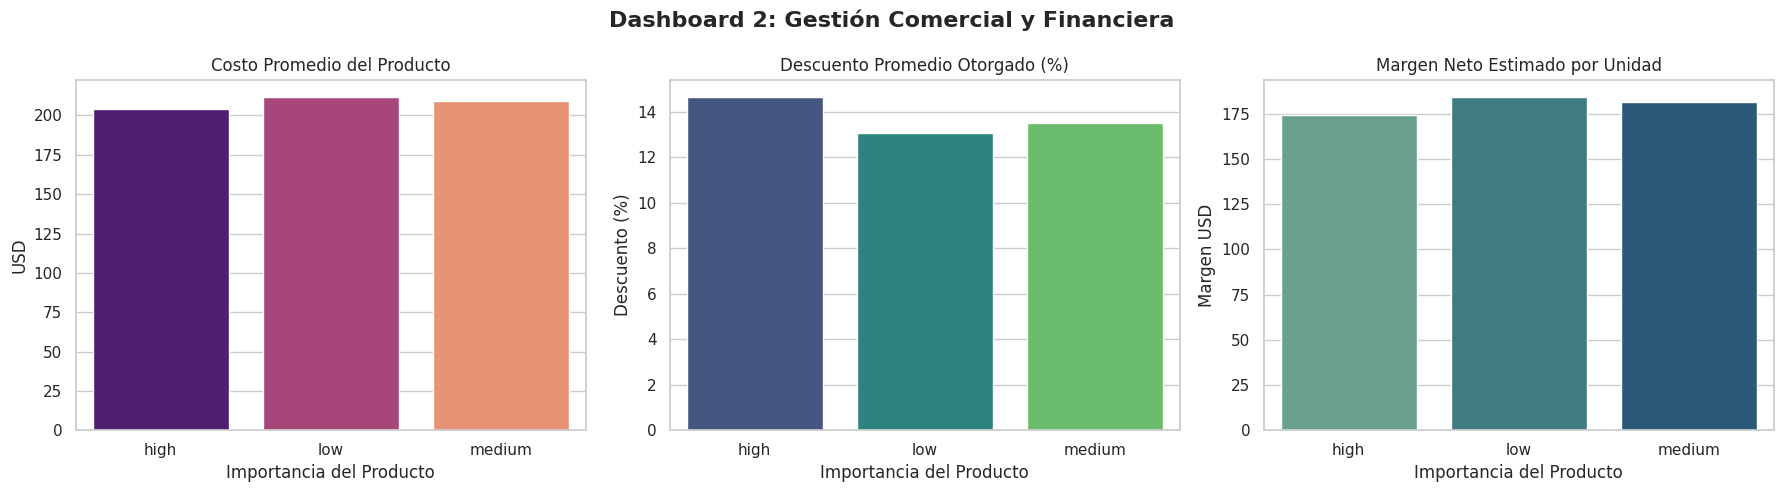

In [115]:

kpi2_3 = data.groupby('Product_importance').agg(
    Costo_Promedio=('Cost_of_the_Product', 'mean'),
    Descuento_Promedio=('Discount_offered', 'mean')
).reset_index()
kpi2_3['Margen_Neto_Estimado'] = kpi2_3['Costo_Promedio'] * (1 - kpi2_3['Descuento_Promedio'] / 100)


fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dashboard 2: Gestión Comercial y Financiera', fontsize=16, fontweight='bold')


sns.barplot(data=kpi2_3, x='Product_importance', y='Costo_Promedio', ax=axs[0], palette='magma', hue='Product_importance', legend=False)
axs[0].set_title('Costo Promedio del Producto')
axs[0].set_xlabel('Importancia del Producto')
axs[0].set_ylabel('USD')


sns.barplot(data=kpi2_3, x='Product_importance', y='Descuento_Promedio', ax=axs[1], palette='viridis', hue='Product_importance', legend=False)
axs[1].set_title('Descuento Promedio Otorgado (%)')
axs[1].set_xlabel('Importancia del Producto')
axs[1].set_ylabel('Descuento (%)')


sns.barplot(data=kpi2_3, x='Product_importance', y='Margen_Neto_Estimado', ax=axs[2], palette='crest', hue='Product_importance', legend=False)
axs[2].set_title('Margen Neto Estimado por Unidad')
axs[2].set_xlabel('Importancia del Producto')
axs[2].set_ylabel('Margen USD')

plt.tight_layout()
plt.show()

### 3. KPIs de Experiencia y Fidelización del Cliente (Customer Experience - CX)

Diseñados para evaluar la satisfacción y la carga de soporte post-venta.

3.1. **Índice de Satisfacción del Cliente (CSAT) Promedio:** El promedio de la variable `Customer rating` (escala 1 a 5). Se puede segmentar por género o por bloque de bodega para ver si hay anomalías.

3.2. **Tasa de Retención / Clientes Recurrentes:** Analizar la distribución de `Prior purchases` para determinar qué porcentaje de la base de datos son clientes nuevos (0-1 compras previas) vs. clientes fidelizados (2 o más compras).

3.3. **Carga de Soporte por Cliente (Customer Care Calls):** Promedio de llamadas de consulta realizadas. Permite analizar si a mayor costo del producto o menores calificaciones, aumentan las llamadas de reclamo.

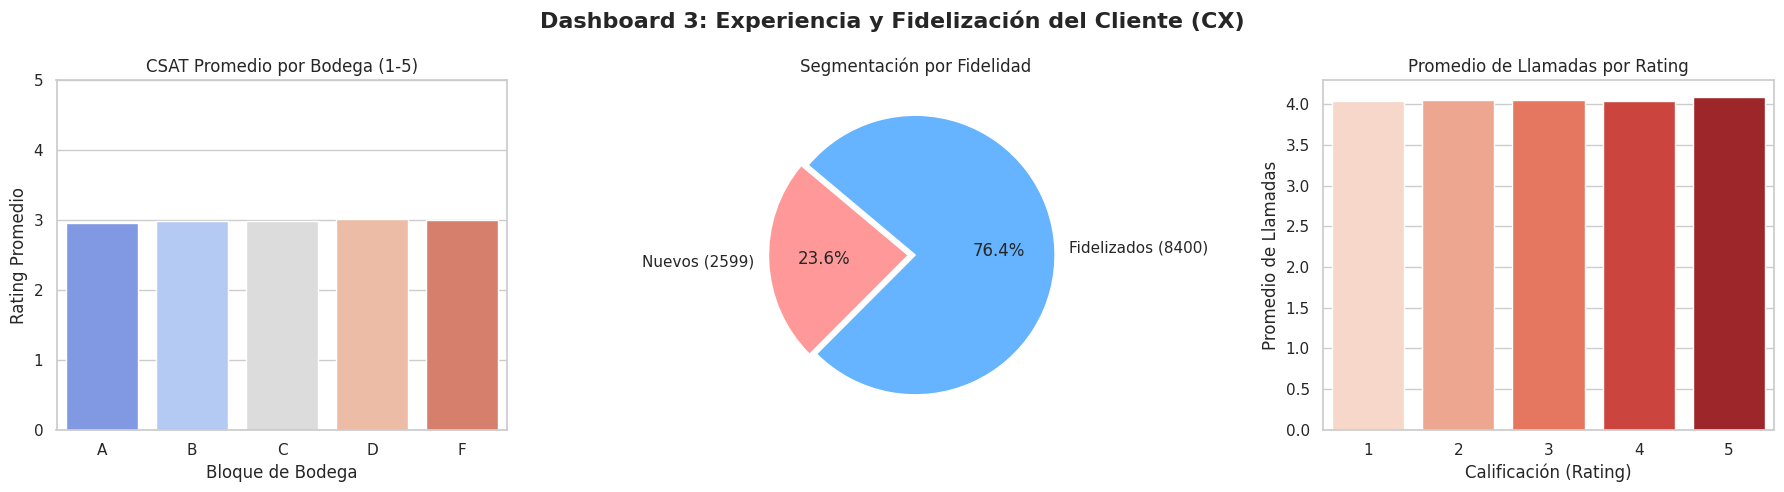

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns


csat_por_bodega = data.groupby('Warehouse_block')['Customer_rating'].mean().reset_index()



nuevos = (data['Prior_purchases'] == 2).sum()
recurrentes = (data['Prior_purchases'] >= 3).sum()


carga_por_rating = data.groupby('Customer_rating')['Customer_care_calls'].mean().reset_index()
carga_por_rating['Customer_rating'] = carga_por_rating['Customer_rating'].astype(str)


fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dashboard 3: Experiencia y Fidelización del Cliente (CX)', fontsize=16, fontweight='bold')

sns.barplot(data=csat_por_bodega, x='Warehouse_block', y='Customer_rating', ax=axs[0], palette='coolwarm', hue='Warehouse_block', legend=False)
axs[0].set_title('CSAT Promedio por Bodega (1-5)')
axs[0].set_ylim(0, 5)
axs[0].set_xlabel('Bloque de Bodega')
axs[0].set_ylabel('Rating Promedio')


axs[1].pie([nuevos, recurrentes], labels=[f'Nuevos ({nuevos})', f'Fidelizados ({recurrentes})'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140, explode=(0.05, 0))
axs[1].set_title('Segmentación por Fidelidad')


sns.barplot(data=carga_por_rating, x='Customer_rating', y='Customer_care_calls', ax=axs[2], palette='Reds', hue='Customer_rating', legend=False)
axs[2].set_title('Promedio de Llamadas por Rating')
axs[2].set_xlabel('Calificación (Rating)')
axs[2].set_ylabel('Promedio de Llamadas')

plt.tight_layout()
plt.show()
